# 05 — SQL Analysis
**Customer Churn Project**  
Connecting to Microsoft SQL Server and running analytical queries on the churn dataset.

## 1. Setup & Connection

In [1]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Connection to SQL Server
conn = pyodbc.connect(
    "DRIVER={SQL Server};"
    "SERVER=OMAR-ZIZO;"
    "DATABASE=customer_churn;"
    "Trusted_Connection=yes;"
)

print("Connected to SQL Server successfully!")

Connected to SQL Server successfully!


## 2. Query 1 — Overall Churn Rate

In [2]:
query1 = """
SELECT
    COUNT(*) AS total_customers,
    SUM(churn) AS churned,
    ROUND(AVG(CAST(churn AS FLOAT)) * 100, 2) AS churn_rate
FROM customers;
"""

df_q1 = pd.read_sql(query1, conn)
df_q1

C:\Users\OVER CLOCK\AppData\Local\Temp\ipykernel_2080\2867982078.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q1 = pd.read_sql(query1, conn)


,total_customers,churned,churn_rate
0,999999,99227,9.92


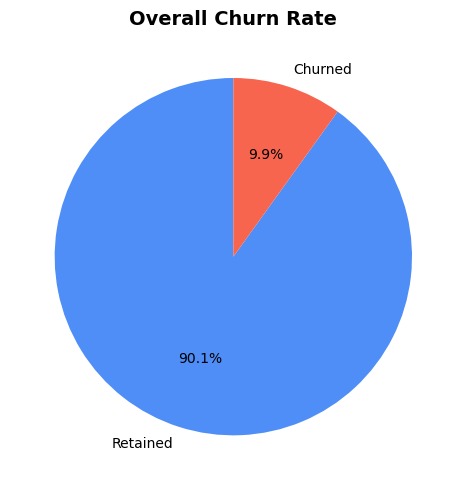

Total Customers : 999,999
Churned         : 99,227
Churn Rate      : 9.92%


In [3]:
# Visualization
churned = df_q1['churned'].values[0]
retained = df_q1['total_customers'].values[0] - churned

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    [retained, churned],
    labels=['Retained', 'Churned'],
    colors=['#4f8ef7', '#f7654f'],
    autopct='%1.1f%%',
    startangle=90
)
ax.set_title('Overall Churn Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Total Customers : {df_q1['total_customers'].values[0]:,}")
print(f"Churned         : {churned:,}")
print(f"Churn Rate      : {df_q1['churn_rate'].values[0]}%")

**Insight:** The overall churn rate is ~9.9%, meaning roughly 1 in 10 customers leaves the company.

## 3. Query 2 — Churn Rate by Contract Type

In [4]:
query2 = """
SELECT
    contract,
    COUNT(*) AS total,
    SUM(churn) AS churned,
    ROUND(AVG(CAST(churn AS FLOAT)) * 100, 2) AS churn_rate
FROM customers
GROUP BY contract
ORDER BY churn_rate DESC;
"""

df_q2 = pd.read_sql(query2, conn)

# Map encoded values back to labels
contract_map = {0: 'Month-to-Month', 1: 'One Year', 2: 'Two Year'}
df_q2['contract_label'] = df_q2['contract'].map(contract_map)
df_q2[['contract_label', 'total', 'churned', 'churn_rate']]

C:\Users\OVER CLOCK\AppData\Local\Temp\ipykernel_2080\2811017902.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q2 = pd.read_sql(query2, conn)


,contract_label,total,churned,churn_rate
0,Month-to-Month,19992,5299,26.51
1,One Year,550468,69651,12.65
2,Two Year,429539,24277,5.65


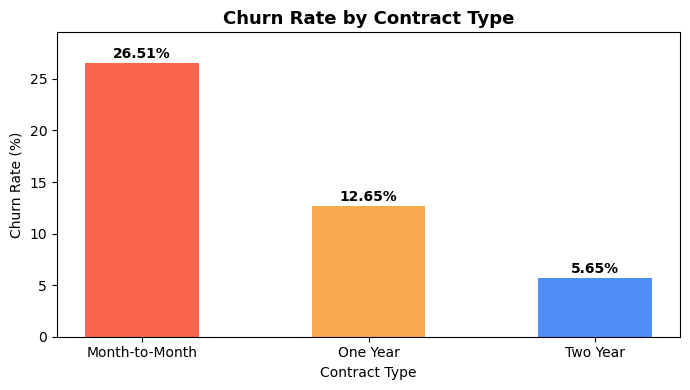

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    df_q2['contract_label'],
    df_q2['churn_rate'],
    color=['#f7654f', '#f7a94f', '#4f8ef7'],
    edgecolor='none',
    width=0.5
)
for bar, val in zip(bars, df_q2['churn_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val}%', ha='center', va='bottom', fontweight='bold')
ax.set_title('Churn Rate by Contract Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, df_q2['churn_rate'].max() + 3)
plt.tight_layout()
plt.show()

**Insight:** Month-to-Month customers have the highest churn rate. Customers on longer contracts are significantly more loyal.

## 4. Query 3 — High-Risk Customers (Not Yet Churned)

In [6]:
query3 = """
SELECT TOP 100
    customer_id,
    num_complaints,
    customer_satisfaction,
    contract,
    churn
FROM customers
WHERE num_complaints > 0
  AND customer_satisfaction < 0
  AND churn = 0
ORDER BY num_complaints DESC;
"""

df_q3 = pd.read_sql(query3, conn)
df_q3['contract_label'] = df_q3['contract'].map(contract_map)
df_q3.head(10)

C:\Users\OVER CLOCK\AppData\Local\Temp\ipykernel_2080\3890481506.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q3 = pd.read_sql(query3, conn)


,customer_id,num_complaints,customer_satisfaction,contract,churn,contract_label
0,160873,7.594331,-0.075524,2.0,0,Two Year
1,746840,7.594331,-0.508728,1.0,0,One Year
2,821278,7.594331,-1.808338,2.0,0,Two Year
3,940033,7.594331,-0.941931,1.0,0,One Year
4,20993,6.386751,-1.808338,2.0,0,Two Year
5,31848,6.386751,-0.941931,2.0,0,Two Year
6,88451,6.386751,-0.941931,2.0,0,Two Year
7,111210,6.386751,-0.508728,2.0,0,Two Year
8,151474,6.386751,-0.075524,1.0,0,One Year
9,170845,6.386751,-0.075524,1.0,0,One Year


In [7]:
print(f"High-risk customers identified: {len(df_q3)}")
print(f"\nContract distribution among high-risk customers:")
print(df_q3['contract_label'].value_counts())

High-risk customers identified: 100

Contract distribution among high-risk customers:
contract_label
Two Year          53
One Year          45
Month-to-Month     2
Name: count, dtype: int64


**Insight:** These are customers who haven't churned yet but show warning signs — high complaints and low satisfaction. These should be prioritized for retention campaigns.

## 5. Query 4 — Churn Rate by Monthly Charges

In [8]:
query4 = """
SELECT
    CASE
        WHEN monthlycharges < -0.5 THEN 'Low'
        WHEN monthlycharges < 0.5  THEN 'Medium'
        ELSE 'High'
    END AS charge_level,
    COUNT(*) AS total,
    SUM(churn) AS churned,
    ROUND(AVG(CAST(churn AS FLOAT)) * 100, 2) AS churn_rate
FROM customers
GROUP BY
    CASE
        WHEN monthlycharges < -0.5 THEN 'Low'
        WHEN monthlycharges < 0.5  THEN 'Medium'
        ELSE 'High'
    END
ORDER BY churn_rate DESC;
"""

df_q4 = pd.read_sql(query4, conn)
df_q4

C:\Users\OVER CLOCK\AppData\Local\Temp\ipykernel_2080\1087937294.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q4 = pd.read_sql(query4, conn)


,charge_level,total,churned,churn_rate
0,Low,281015,29158,10.38
1,Medium,463308,46508,10.04
2,High,255676,23561,9.22


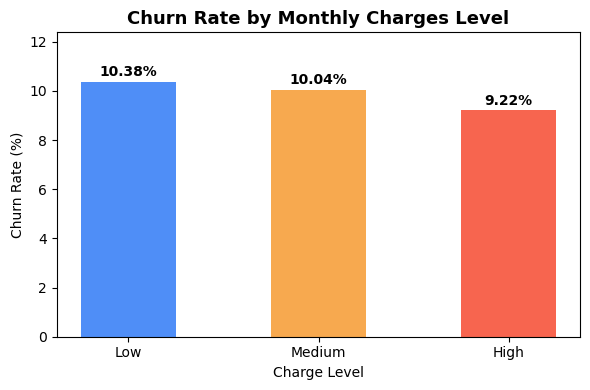

In [9]:
order = ['Low', 'Medium', 'High']
df_q4 = df_q4.set_index('charge_level').reindex(order).reset_index()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    df_q4['charge_level'],
    df_q4['churn_rate'],
    color=['#4f8ef7', '#f7a94f', '#f7654f'],
    edgecolor='none',
    width=0.5
)
for bar, val in zip(bars, df_q4['churn_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val}%', ha='center', va='bottom', fontweight='bold')
ax.set_title('Churn Rate by Monthly Charges Level', fontsize=13, fontweight='bold')
ax.set_xlabel('Charge Level')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, df_q4['churn_rate'].max() + 2)
plt.tight_layout()
plt.show()

**Insight:** Customers paying higher monthly charges tend to churn more — possibly switching to cheaper competitors.

## 6. Query 5 — Churn Rate by Customer Tenure

In [10]:
query5 = """
SELECT
    CASE
        WHEN tenure < -0.5 THEN 'New (< 1yr)'
        WHEN tenure < 0.5  THEN 'Mid (1-3yr)'
        ELSE 'Loyal (3yr+)'
    END AS tenure_group,
    COUNT(*) AS total,
    SUM(churn) AS churned,
    ROUND(AVG(CAST(churn AS FLOAT)) * 100, 2) AS churn_rate
FROM customers
GROUP BY
    CASE
        WHEN tenure < -0.5 THEN 'New (< 1yr)'
        WHEN tenure < 0.5  THEN 'Mid (1-3yr)'
        ELSE 'Loyal (3yr+)'
    END
ORDER BY churn_rate DESC;
"""

df_q5 = pd.read_sql(query5, conn)
df_q5

C:\Users\OVER CLOCK\AppData\Local\Temp\ipykernel_2080\3806629112.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q5 = pd.read_sql(query5, conn)


,tenure_group,total,churned,churn_rate
0,New (< 1yr),418054,42886,10.26
1,Mid (1-3yr),329206,32757,9.95
2,Loyal (3yr+),252739,23584,9.33


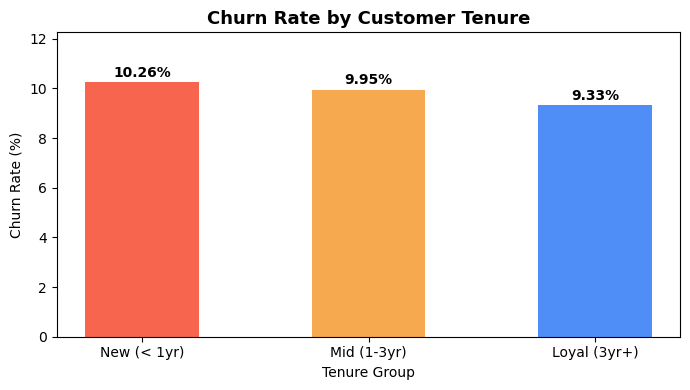

In [11]:
order5 = ['New (< 1yr)', 'Mid (1-3yr)', 'Loyal (3yr+)']
df_q5_sorted = df_q5.set_index('tenure_group').reindex(order5).reset_index()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    df_q5_sorted['tenure_group'].astype(str),
    df_q5_sorted['churn_rate'],
    color=['#f7654f', '#f7a94f', '#4f8ef7'],
    edgecolor='none',
    width=0.5
)
for bar, val in zip(bars, df_q5_sorted['churn_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val}%', ha='center', va='bottom', fontweight='bold')
ax.set_title('Churn Rate by Customer Tenure', fontsize=13, fontweight='bold')
ax.set_xlabel('Tenure Group')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, df_q5_sorted['churn_rate'].max() + 2)
plt.tight_layout()
plt.show()

**Insight:** New customers (< 1 year) have the highest churn rate. Loyalty programs targeting early-stage customers could significantly reduce churn.

## 7. Summary of SQL Insights

| Query | Finding |
|---|---|
| Overall Churn Rate | ~9.9% of customers churn |
| Contract Type | Month-to-Month has the highest churn rate |
| High-Risk Customers | 100 at-risk customers identified for retention |
| Monthly Charges | High-paying customers churn more |
| Tenure | New customers (< 1yr) are most likely to leave |

In [12]:
conn.close()
print("Connection closed.")

Connection closed.
